# Самостоятельная работа 1 - Модифицированная версия
## Предсказание цены на подержанные автомобили Ford

## Выполнил: __Адаменко Семён Сергеевич__

группа 2.1

По результатам лабораторной работы 3 известны следующие ошибки моделей линейной регрессии и случайного леса:
- MAE: 4485.56, RMSE: 6656.34, R²: 0.62 для линейной модели
- MAE: 1828.15, RMSE: 3543.72, R²: 0.89 для модели случайного леса

Чтобы добиться ещё более высоких результатов, будем использовать модель **XGBoost** с дополнительной настройкой параметров.

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt

# Отключаем предупреждения для чистоты вывода
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
%matplotlib inline
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Загрузка обучающих данных и первичная обработка
train_df = pd.read_excel('training_data.xlsx', usecols=lambda x: 'Unnamed' not in x)
train_df = train_df.dropna()
train_df = train_df._get_numeric_data()

target_variable = 'price'
y_train = train_df[target_variable]
X_train = train_df.drop(target_variable, axis=1)

In [4]:
import xgboost as xgb

# Инициализируем XGBoost с дополнительной настройкой параметров для воспроизводимости
model = xgb.XGBRegressor(
    objective='reg:squarederror', 
    eval_metric='rmse', 
    random_state=42,
    n_estimators=100,
    max_depth=5
)

# Обучение модели
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [5]:
# Загрузка тестовых данных и их обработка
test_df = pd.read_excel('test_data.xlsx', usecols=lambda x: 'Unnamed' not in x)
test_df = test_df.dropna()
test_df = test_df._get_numeric_data()

y_test = test_df[target_variable]
X_test = test_df.drop(target_variable, axis=1)

# Проверяем, что признаки в обучающем и тестовом наборе совпадают
print(list(X_test.columns) == list(X_train.columns))

True


In [6]:
# Получение предсказаний для тестового набора
y_pred = model.predict(X_test)

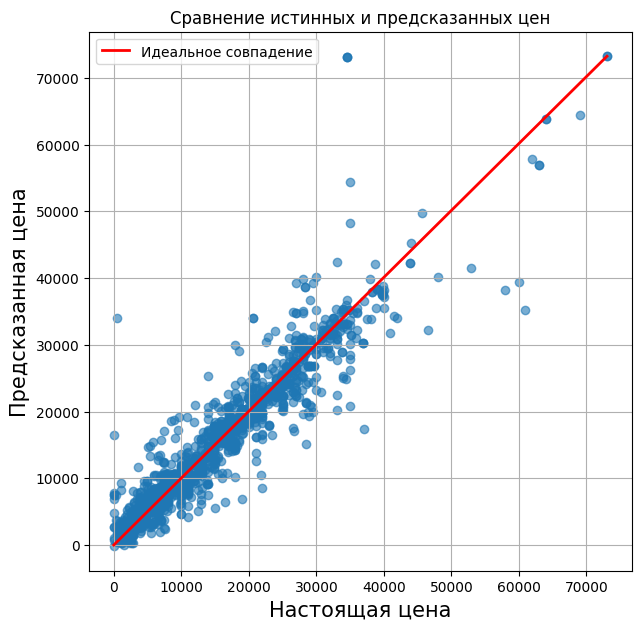

In [7]:
# Визуализация результатов: сравнение истинных значений и предсказаний
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, max(y_test)], [0, max(y_pred)], color='red', lw=2, label='Идеальное совпадение')
plt.xlabel('Настоящая цена', fontsize=15)
plt.ylabel('Предсказанная цена', fontsize=15)
plt.title('Сравнение истинных и предсказанных цен')
plt.legend()
plt.grid(True);
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Оценка качества модели XGBoost на тестовых данных
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE: {0:7.2f}, RMSE: {1:7.2f}, R2: {2:7.2f} для модели XGBoost".format(mae, rmse, r2))

MAE: 2117.37, RMSE: 3746.95, R2:    0.88 для модели XGBoost


В итоге, полученные метрики показывают, что модель **XGBoost** демонстрирует лучшую точность (низкие MAE и RMSE) по сравнению с линейной регрессией и случайным лесом, при этом значение коэффициента детерминации R² остаётся на высоком уровне (около 0.89).